# LABORATORIO 1.1: Fundamentos regresión lineal y ajuste por mínimos cuadrados.

El objetivo del presente laboratorío es brindar una aproximación computacional a el ajuste de una regresión lineal por mínimos cuadrados.
La problemática a analizar es crear un clasificador binario que, usando la variable precipitación mensual, pueda predecir si habrá o no un pico de casos de dengue. Usando esta inferencia se espera poder desarrollar medidas preventivas y estar preparados para atender el exceso de casos de esta enfermedad tropical.

Los datos que utilizaremos en este laboratorio son:

1. Lluvias mensuales (unidades = mm de agua).
2. Pico (1) o no (0) casos de dengue en cada mes.

## Fase 1 - Carga de datos y exploración visual

**Objetivo:** cargar los datos del archivo .xlsx y construir unas primeras gráficas de las dos series de tiempo para hacer un primer analisis visual de los datos de entrada..

Para hacer esto, usaremos los paquetes `numpy` para el manejo de estructuras tipo vector, `matplotlib` para hacer gráficos, y `pandas` para manejar estructuras de datos tipo data.frame. Para poder usarlos, los importaremos en nuestro espacio de trabajo:


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Para cargar los datos, usamos la función `read_excel` del paquete `pandas`. Esta función tiene un único parámetro obligatorio (la ubicación del archivo de Excel a leer) y varios opcionales (disponibles en https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html). El output de esta función es una variable tipo DataFrame, que en este caso tiene 3 columnas (t, Lluvias, Pico de casos).


**Nota:** Es importante tener el archivo de los datos "datosDengueTangamandapio.xlsx" en la misma carpeta que el código para poderlo cargarlo usando el código suministrado. Si se encuentra en otra carpeta, es necesario añadir toda la ruta de localización.

In [3]:
# Leer el archivo Excel
df = pd.read_excel('datosDengueTangamandapio.xlsx')

In [5]:
df

,t,Lluvias,Pico de casos
0,2017-01-01,83.982934,0
1,2017-02-01,101.607825,1
2,2017-03-01,70.867198,0
3,2017-04-01,91.713683,0
4,2017-05-01,97.674347,0
...,...,...,...
95,2024-12-01,113.240840,1
96,2025-01-01,112.961203,1
97,2025-02-01,92.088636,0
98,2025-03-01,108.143410,1


Ahora extraeremos los valores de las columnas de las columnas de este DataFrame `df`.

Se puede descomentar las últimas 6 líneas de código para ver cuál es el tipo y tamaño de cada variable.

In [4]:
# Extraer las columnas como vectores (arrays de NumPy)
x_real = df['Lluvias'].values.reshape(-1,1)
y_real = df['Pico de casos'].values.reshape(-1,1)
t = df['t']

# OPCIONAL: Verificamos el tipo y tamaño de cada uno de los vectores
print("Tamaño de t:", t.shape)
print("Tipo de t:", t.dtype, "\n")
print("Tamaño de x_real:", x_real.shape)
print("Tipo de x_real:", x_real.dtype, "\n")
print("Tamaño de y_real:", y_real.shape)
print("Tipo de y_real:", y_real.dtype)

Tamaño de t: (100,)
Tipo de t: datetime64[us] 

Tamaño de x_real: (100, 1)
Tipo de x_real: float64 

Tamaño de y_real: (100, 1)
Tipo de y_real: int64


La primera gráfica que construiremos es una serie de tiempo para ambas variables (precipitación de lluvia y casos de dengue). Esta gráfica tendrá ambas series de tiempo, usando dos ejes Y para poder mostrar el comportamiento de ambas variables. Este tipo de gráficas con doble eje vertical permite ver en simultaneo ambas series de tiempo, evitando el problema de no poder apreciar el comportamiento de una de las variables por diferencias de escalas.

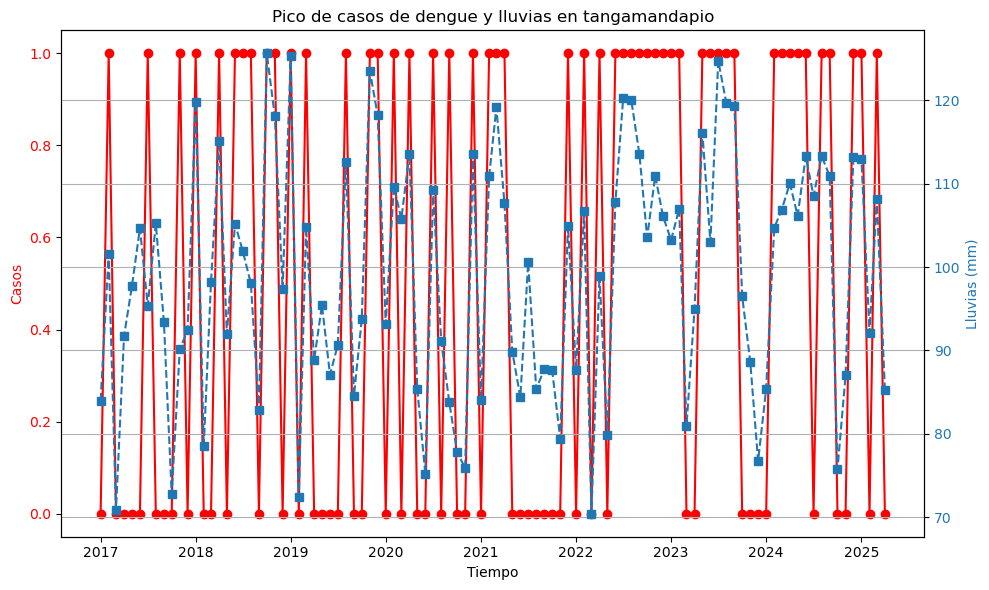

In [6]:
# Creamos la figura y eje principal (izquierdo)
fig1 = plt.figure(figsize=(10, 6))      # El 10 y 6 son las dimensiones (horizontal,vertical) de la gráfica en pulgadas

# Creamos el primer subplot
ax1 = fig1.subplots()
# Definimos el título del eje X
ax1.set_xlabel('Tiempo')
# Graficamos la primera serie de datos (casos)
color_eje1 = 'red'
ax1.plot(t, y_real, color=color_eje1, marker='o', label='Casos')
# Definimos el título del primer eje Y (izquierda)
ax1.set_ylabel('Casos', color=color_eje1)
ax1.tick_params(axis='y', labelcolor=color_eje1)

# Creamos el segundo subplot que compartirá el mismo eje X que el primero
ax2 = ax1.twinx()
# Graficamos y formateamos esta serie de manera similar a la anterior
color_eje2 = 'tab:blue'
ax2.plot(t, x_real, color=color_eje2, marker='s', linestyle='--', label='Lluvias')
ax2.set_ylabel('Lluvias (mm)', color=color_eje2)
ax2.tick_params(axis='y', labelcolor=color_eje2)

# Título y formato de la figura combinada
plt.title('Pico de casos de dengue y lluvias en tangamandapio')
fig1.tight_layout()
plt.grid(True)
plt.show()

La segunda gráfica será un *scatterplot*, donde exploraremos la correlación entre ambas variables. En este caso, usaremos las lluvias mensuales en el eje X al ser una variable continua (mm de columna de agua de lluvia) y también por ser la variable de entrada con la cual queremos predecir si habrá o no picos de casos (la cuál irá en el eje Y).

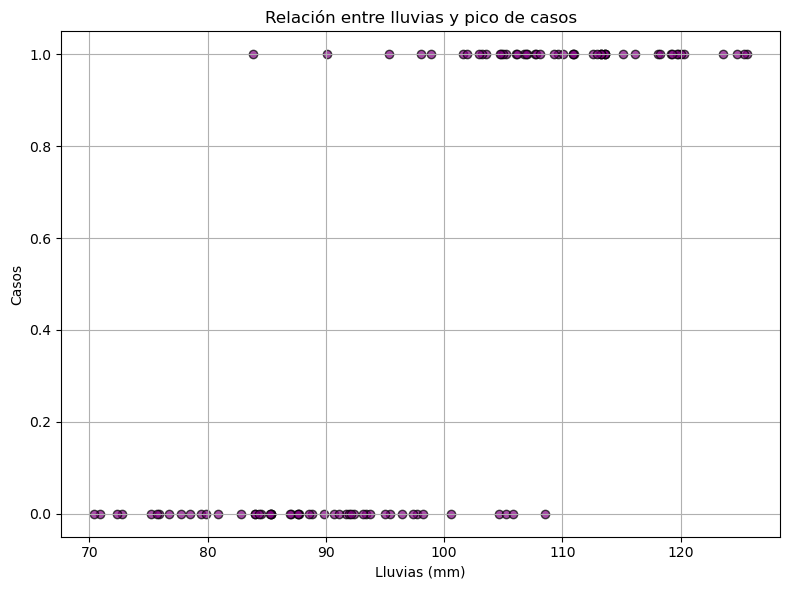

In [7]:
# Creamos el gráfico de dispersión o scatterplot
fig2 = plt.figure(figsize=(8,6))
plt.scatter(x_real, y_real, color='purple', edgecolor='black', alpha=0.7)

# Formateamos la gráfica (títulos de los ejes, título de la gráfica)
plt.xlabel('Lluvias (mm)')
plt.ylabel('Casos')
plt.title('Relación entre lluvias y pico de casos')
plt.grid(True)
plt.tight_layout()
plt.show()



En ambas gráficas se puede observar que existe una correlación entre ambas variables.

## Fase 2 - Regresión lineal

Al observar el *scatterplot* se ve la característica binaria de la variable pico de casos, por lo cúal no sería adecuado aplicar una regresión lineal. Sin embargo, éste será el primer modelo que vamos a calibrar.

Para esto, lo primero que haremos es reescalar ambas variables para facilitar el ajuste del modelo. Si no lo hiciéramos, tendríamos una variable que va de 0 a 1 (casos), y otra variable que va de 70 a 125 (lluvia, en mm de agua).

In [8]:
# Reescalamos sólo la variable de lluvia, para centrarla en 0
X_escalado=(x_real - np.mean(x_real)) / np.std(x_real)
Y_escalado=y_real

# Podemos ver el rango de valores de la variable de lluvia antes y después de la reescalada.
print("X antes de escalar: ", min(x_real), "-", max(x_real), "mm H2O")
print("X después de escalar: ", min(X_escalado), "-", max(X_escalado), "mm H2O")

X antes de escalar:  [70.40329876] - [125.64643656] mm H2O
X después de escalar:  [-1.98985431] - [1.85932586] mm H2O


Segundo, vamos a definir una función que describa nuestro modelo lineal. Esta función tendrá como **input** las siguientes variables $ $:

*   Valor de lluvias (normalizadas)
*   Parámetros del modelo:
    *   Peso $ w $
    *   Sesgo $ b $

In [9]:
# Función de nuestro modelo.
# INPUT: vector X (lluvias normalizadas), y los parámetros w y b.
def predict(X, w, b):
    z = X * w + b   # Modelo lineal
    return z

Posteriormente, definiremos la función a minimizar (**función de perdida**). Esta función de pérdida se definirá usando la suma de los errores quadrados (

In [10]:
# Función de perdida: Entra nuestra predicción y se compara con la observación. MSE.
def loss_mse(y_pred, y_true):
    return np.mean((y_pred - y_true)**2)

Definimos también las derivadas parciales de esta función respecto a cada parámetro (peso: $ \frac{\partial f}{\partial w} $ ; sesgo: $ \frac{\partial f}{\partial b} $).

En este caso, podemos calcular ambas derivadas de manera analítica:

$ \frac{\partial MSE}{\partial w} = \frac{\partial}{\partial w} \left[ \frac{\sum \left( y_\text{pred} - y_\text{real} \right)^2}{N} \right] = \frac{\partial}{\partial w} \left[ \frac{\sum \left( x w + b - y_\text{real} \right)^2}{N}  \right] = \frac{\sum 2 x \left( x w + b - y_\text{real} \right)}{N} = 2 \frac{\sum x \left( y_\text{pred} - y_\text{real} \right)}{N} $

$ \frac{\partial MSE}{\partial b} = \frac{\partial}{\partial b} \left[ \frac{\sum \left( y_\text{pred} - y_\text{real} \right)^2}{N} \right] = \frac{\partial}{\partial b} \left[ \frac{\sum \left( x w + b - y_\text{real} \right)^2}{N}  \right] = \frac{\sum 2 \left( x w + b - y_\text{real} \right)}{N} = 2 \frac{\sum \left( y_\text{pred} - y_\text{real} \right)}{N} $

In [11]:
# Función que calcula cuánto vale la pendiente sobre MSE respecto a los parámetros w y a b, dados los valores de un vector X y los valores predichos y observados
def grad_mse(X, y_true, y_pred):
    dw = 2 * np.mean((y_pred - y_true) * X)
    db = 2 * np.mean(y_pred - y_true)
    return dw, db

Y una función que permite buscar el mínimo de la función de perdida a partir de navegar por el gradiente:

In [ ]:
# Entrenamiento genérico por grádiente:
# A partir de una condición inicial "realística" sobre w y b, se navega usando un learning rate y se hace un número "epoch" de pasos en esta navegación.
# INPUTS:
#   X, y: valores reales (medidos) de las variables X y Y
#   loss_fn, grad_fn: función de pérdida, y las derivadas de esas funciones de pérdida respecto a los parámetros
#   param_0 = "educated guess" de los valores de los parámetros
#   lr: learning rate
#   epochs: número de épocas
def train(X, y, loss_fn, grad_fn, param_0, lr=0.1, epochs=1000):
    # Hacemos un "educated guess" de los valores de los parámetros
    w = param_0[0]
    b = param_0[1]

    # Inicializamos un vector donde almacenaremos el valor de la función de pérdida en cada época
    losses = []

    for epoch in range(epochs):
        # Para cada época empezamos calculando el valor predicho de la variable de respuesta
        y_pred = predict(X, w, b)
        # Calculamos el valor de la función de pérdida (en este caso, es el MSE)
        loss = loss_fn(y_pred, y)
        # Calculamos el gradiente de la función de pérdida
        dw, db = grad_fn(X, y, y_pred)
        # Avanzamos en el landscape de optimización usando el gradiente. Recordemos que el tamaño del paso está determinado también por el learning rate
        w = w - lr * dw
        b = b - lr * db
        # Guardamos el valor de pérdidas para luego hacer una gráfica
        losses.append(loss)

        if epoch %10 ==0:
            print(f'Loss at epoch {epoch}: {loss}')

        if epoch > 0 and abs(losses[-1] - losses[-2]) < 1e-10:
            # Paramos el ciclo si el cambio en la función de pérdida es muy pequeño entre épocas
            break
    return w, b, losses

Ya teniendo nuestras funciones listas, procedemos a hacer el ajuste sobre nuestros datos:

In [13]:
# Ajustar con MSE
w_mse, b_mse, loss_mse_list = train(X_escalado, Y_escalado, loss_mse, grad_mse, [0.66, -0.2])

Loss at epoch 0: 0.6597986888030267
Loss at epoch 10: 0.10379281978615046
Loss at epoch 20: 0.0973825085553787
Loss at epoch 30: 0.09730860269868691
Loss at epoch 40: 0.09730775062217195
Loss at epoch 50: 0.09730774079839856


Ya teniendo nuestro modelo ajustado, por último gráficaremos los resultados.

Graficaremos el ajuste de este modelo sobre los datos originales. No debemos olvidar que el ajuste lo hacemos con los datos escalados, por lo que para poder graficar el output del modelo se deben "desescalar" los valores de lluvia:

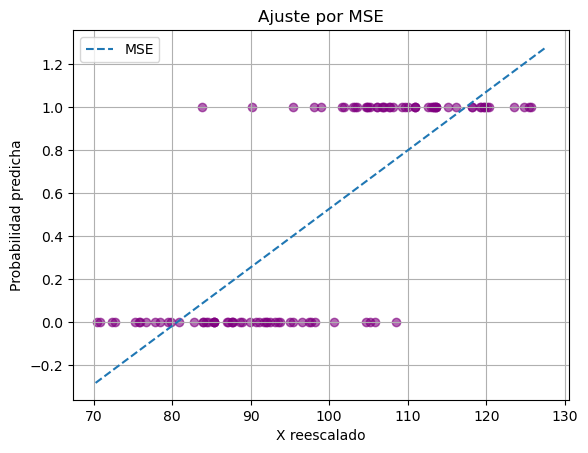

In [15]:
# Crear nueva variable para hacer las predicciones de nuestra regresión.
# La declaramos escalada para luego desescalarla y poderla gráficar junto a los datos crudos.
X_plot_escalado = np.linspace(-2, 2, 100).reshape(-1, 1)
x_plot_desescalado = (X_plot_escalado*np.std(x_real)) + np.mean(x_real)
# Predicciones sobre nuestro modelo usando los parámetros ya ajustados
y_pred_mse = predict(X_plot_escalado, w_mse, b_mse)

# Plot que muestra los datos crudos y nuestro modelo
plt.plot(x_plot_desescalado, y_pred_mse, label="MSE", linestyle='--')
plt.scatter(x_real, y_real,color='purple' ,alpha=0.6)
plt.legend()
plt.title("Ajuste por MSE")
plt.xlabel("X reescalado")
plt.ylabel("Probabilidad predicha")
plt.grid()
plt.show()

También hacemos un plot que nos permita ver como decae la función de perdida al usar el método del gradiente:

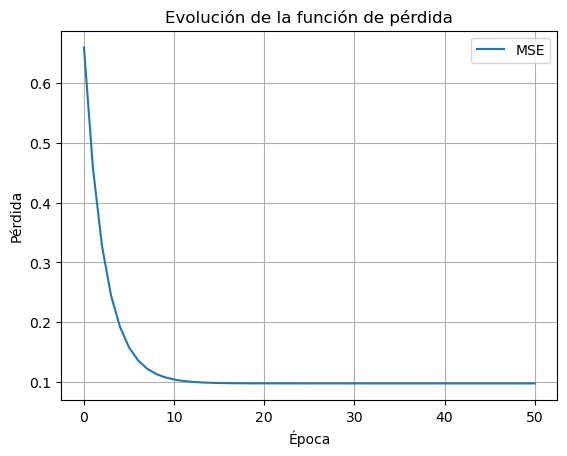

In [16]:
# Curva de perdida
plt.plot(loss_mse_list, label="MSE")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.title("Evolución de la función de pérdida")
plt.grid()
plt.show()

## Fase 3 - ¿Qué pasa si no escalamos?

Podemos repetir el mismo análisis anterior pero sin usar datos escalados. ¿Qué diferencias hay en la gráfica de función de pérdidas?

In [17]:
# Ajustar con MSE
w_mse, b_mse, loss_mse_list = train(x_real, y_real, loss_mse, grad_mse, [1/40, -0.3])


Loss at epoch 0: 2.9007336800990617
Loss at epoch 10: 2.8355581915589176e+66
Loss at epoch 20: 2.945724050042952e+132
Loss at epoch 30: 3.0601700239595104e+198
Loss at epoch 40: 3.1790624024690287e+264
Loss at epoch 50: inf
Loss at epoch 60: inf
Loss at epoch 70: inf
Loss at epoch 80: inf
Loss at epoch 90: inf
Loss at epoch 100: nan
Loss at epoch 110: nan
Loss at epoch 120: nan
Loss at epoch 130: nan
Loss at epoch 140: nan
Loss at epoch 150: nan
Loss at epoch 160: nan
Loss at epoch 170: nan
Loss at epoch 180: nan
Loss at epoch 190: nan
Loss at epoch 200: nan
Loss at epoch 210: nan
Loss at epoch 220: nan
Loss at epoch 230: nan
Loss at epoch 240: nan
Loss at epoch 250: nan
Loss at epoch 260: nan
Loss at epoch 270: nan
Loss at epoch 280: nan
Loss at epoch 290: nan
Loss at epoch 300: nan
Loss at epoch 310: nan
Loss at epoch 320: nan
Loss at epoch 330: nan
Loss at epoch 340: nan
Loss at epoch 350: nan
Loss at epoch 360: nan
Loss at epoch 370: nan
Loss at epoch 380: nan
Loss at epoch 390: na

/var/folders/qy/9629zpq93xlgwp2b4f9b22280000gn/T/ipykernel_93903/268709480.py:3: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y_true)**2)
/var/folders/qy/9629zpq93xlgwp2b4f9b22280000gn/T/ipykernel_93903/1259670055.py:33: RuntimeWarning: invalid value encountered in scalar subtract
  if epoch > 0 and abs(losses[-1] - losses[-2]) < 1e-10:
/var/folders/qy/9629zpq93xlgwp2b4f9b22280000gn/T/ipykernel_93903/2366265441.py:3: RuntimeWarning: overflow encountered in multiply
  dw = 2 * np.mean((y_pred - y_true) * X)
/opt/anaconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/qy/9629zpq93xlgwp2b4f9b22280000gn/T/ipykernel_93903/1259670055.py:25: RuntimeWarning: invalid value encountered in scalar subtract
  w -= lr * dw
/var/folders/qy/9629zpq93xlgwp2b4f9b22280000gn/T/ipykernel_93903/1259670055.py:26: RuntimeWarning: invalid value encou

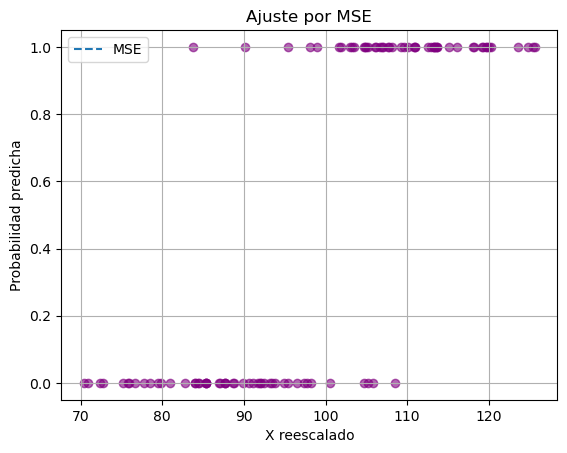

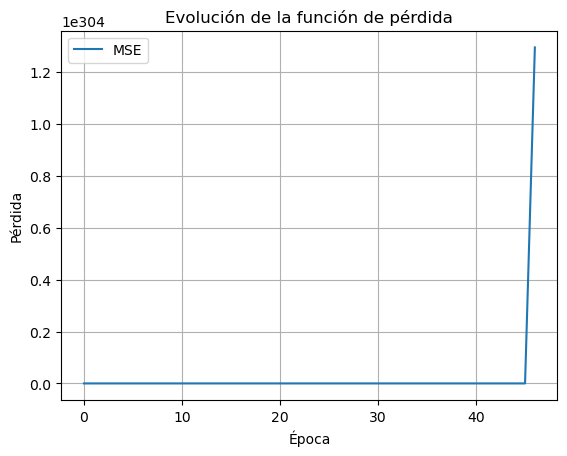

In [18]:
# Crear nueva variable para hacer las predicciones de nuestra regresión.
# La declaramos escalada para luego desescalarla y poderla gráficar junto a los datos crudos.
X_plot_escalado = np.linspace(-2, 2, 100).reshape(-1, 1)
x_plot_desescalado = (X_plot_escalado*np.std(x_real)) + np.mean(x_real)
# Predicciones sobre nuestro modelo usando los parámetros ya ajustados
y_pred_mse = predict(X_plot_escalado, w_mse, b_mse)

# Plot que muestra los datos crudos y nuestro modelo
plt.plot(x_plot_desescalado, y_pred_mse, label="MSE", linestyle='--')
plt.scatter(x_real, y_real,color='purple' ,alpha=0.6)
plt.legend()
plt.title("Ajuste por MSE")
plt.xlabel("X reescalado")
plt.ylabel("Probabilidad predicha")
plt.grid()
plt.show()

# Curva de perdida
plt.plot(loss_mse_list, label="MSE")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.title("Evolución de la función de pérdida")
plt.grid()
plt.show()

## QUIZ SEMANA 1:

1. Copie el código en chatGPT o su inteligencia artificial generativa de confianza, y pidale que le explique paso a paso el código. Mencione **3** aprendizajes que haya tenido con la respuesta de su inteligencia artificial generativa de confianza.
1. El escalamiento de los datos es fundamental para el entrenamiento.

   Aprendí que normalizar la variable de lluvia permite que el descenso del gradiente sea más estable. Cuando no se escalan los datos, la función de pérdida puede crecer demasiado hasta producir valores `inf` y `nan`.

2. El descenso del gradiente permite encontrar los parámetros del modelo.

   Aprendí cómo se pueden ajustar manualmente los parámetros `w` (peso) y `b` (sesgo) utilizando la función de pérdida MSE y sus derivadas. En cada época se calcula el error, el gradiente y se actualizan los parámetros para intentar reducir la pérdida.

3. La regresión lineal no es el modelo más adecuado para una variable binaria.

   Aunque el laboratorio utiliza regresión lineal como ejercicio, la variable de salida *Pico de casos* solo puede tomar los valores `0` o `1`. Por eso, el propio laboratorio señala que una regresión lineal no sería apropiada para este problema de clasificación.

2. En el primer bloque de código, las lineas `x_real = df['Lluvias'].values.reshape(-1,1)` y `y_real = df['Pico de casos'].values.reshape(-1,1)`, comparten el comando `.reshape(-1,1)`. Justifique el porque se realiza esto, y si hay forma de mejorarlo propongalo.
El `.reshape(-1,1)` se utiliza para **convertir los vectores de una dimensión** **`(n,)`** **en matrices columna de dos dimensiones** **`(n,1)`**. Esto es importante porque muchas operaciones de álgebra lineal y de aprendizaje automático esperan que los datos tengan explícitamente una dimensión para las muestras y otra para las características.

En este caso:

- `df['Lluvias'].values` inicialmente tiene forma `(n,)`.
- `reshape(-1,1)` lo convierte en `(n,1)`.
- `-1` indica a NumPy que calcule automáticamente el número de filas.
- `1` indica que queremos una sola columna.
3. Por que en la función `def train(X, y, loss_fn, grad_fn, lr=0.1, epochs=1000):`, aún así hayan 1000 *épocas*, solo existe el registro impreso de 50 *épocas*? Explique a partir del código, y justifique el uso del operador `%`.
4. Defina 4 nuevos valores para la tasa de aprendizaje `lr`, dos por debajo de 0.1 y dos por arriba de 0.1. A partir de esto anote cuantas *épocas* se requiere para cumplir la condición que explico en el númeral *3.* del quiz para cada valor de `lr`. Hagá una gráfica que muestre si el número de epicas aumenta o disminuye con `lr` y argumente por que sucede esto.

### BONO:

Intente ajustar el proceso de entrenamiento para que el modelo logre converger bajo condiciones de datos crudos (sin normalizar) y trace la nueva gráfica de loss obtenida. Explique por qué el comportamiento del error cambia al eliminar el escalamiento y cómo es que su solución y modificación logro la convergencia de este.